In [1]:
import sys
sys.path.append("..")

In [2]:
%load_ext autoreload
%autoreload 2

w1**2/(1 - w1)
w1**2/(1 - w1)**2 + 2*w1/(1 - w1)


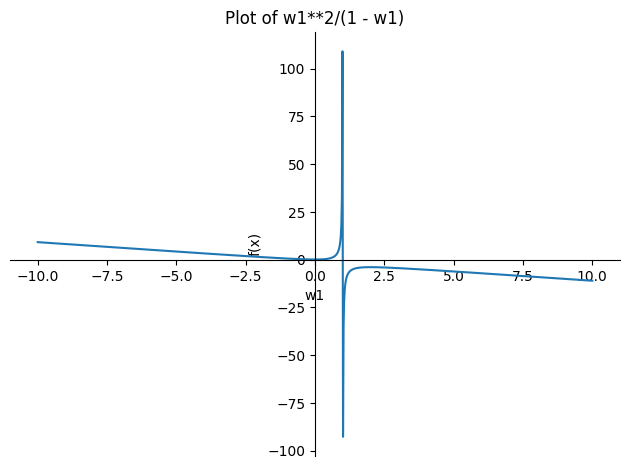

In [3]:

from sympy import symbols
from partialDerivator import compute_partial_derivative, plot_function
from probabilityDistributions import bernoulli_dist

x = 2
w = symbols('w1')
f = bernoulli_dist(x,w)
print(f)
partial_deriv = compute_partial_derivative(f, w)
print(partial_deriv)
plot_function(f, w, (-10, 10))

w1**2 + w2**2
2*w1
2*w2
[2*w1, 2*w2]


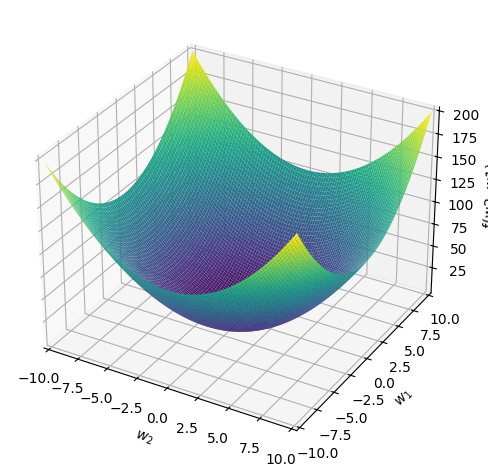

In [4]:
from partialDerivator import compute_partial_derivative, plot_function
from sympy import symbols
import numpy as np


x = np.array([2,2])
w = [symbols('w1'), symbols('w2')]
f = w[0]**x[0] + w[1]**x[1]

print(f)
partial_w0 = compute_partial_derivative(f, w[0])
print(partial_w0)
partial_w1 = compute_partial_derivative(f, w[1])
print(partial_w1)   
gradient = [partial_w0, partial_w1]
print(gradient)
plot_function(f, x, (-10, 10))

## Using Variational Inference Loss

In this experiment, i'm trying to appproximate – in a unsupervised way – a normal distribution using variational inference loss  

In [5]:
from sympy.stats import Normal, sample
from sympy import symbols, Eq, Or
import numpy as np
from sympy.stats import P, Die

truth_mu = 2
truth_sigma = 1
x = Normal('x', truth_mu, truth_sigma)
noise = Normal('noise', 0, 1)
x = x + noise
num_samples = 100
samples_list = list(sample(x, size=num_samples))
samples_list = np.array(samples_list)

x_bold_train, x_bold_eval, x_bold_test = np.split(samples_list, [int(.6 * len(samples_list)), int(.8 * len(samples_list))]) 

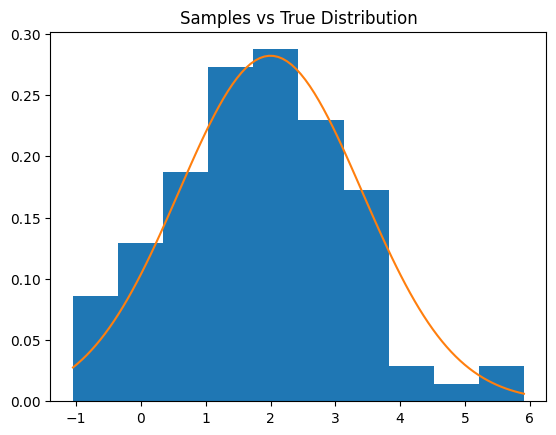

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm

x = np.linspace(min(samples_list), max(samples_list), 100)
pdf = norm.pdf(x, 2, np.sqrt(2))

plt.hist(samples_list, bins=10, density=True)
plt.plot(x, pdf)

plt.title("Samples vs True Distribution")
plt.show()

In [35]:
from univariateGaussianVariationalModel import UnivariateGaussianVariationalModel

model = UnivariateGaussianVariationalModel()
initial_mu_est, initial_sigma_est = model.get_parameters()
model.fit(x_bold_train=x_bold_train, x_bold_val=x_bold_eval, learning_rate=0.0001, epochs=10, patience=10)
mu_est, sigma_est = model.get_parameters()
print("Estimated mu:", mu_est)
print("Estimated sigma:", sigma_est)

Model is not fitted yet.
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
New __has_improved called
Estimated mu: 1.88515270148367
Estimated sigma: 1


In [36]:
ground_truth_parameters = {"mu": 2, "sigma": 1}
initial_parameters = {"mu": initial_mu_est, "sigma": initial_sigma_est}
estimated_parameters = {"mu": mu_est, "sigma": sigma_est}

ground_truth_dist = norm(loc=ground_truth_parameters["mu"], scale=ground_truth_parameters["sigma"])
initial_dist = norm(loc=initial_parameters["mu"], scale=initial_parameters["sigma"])
estimated_dist = norm(loc=estimated_parameters["mu"], scale=estimated_parameters["sigma"])



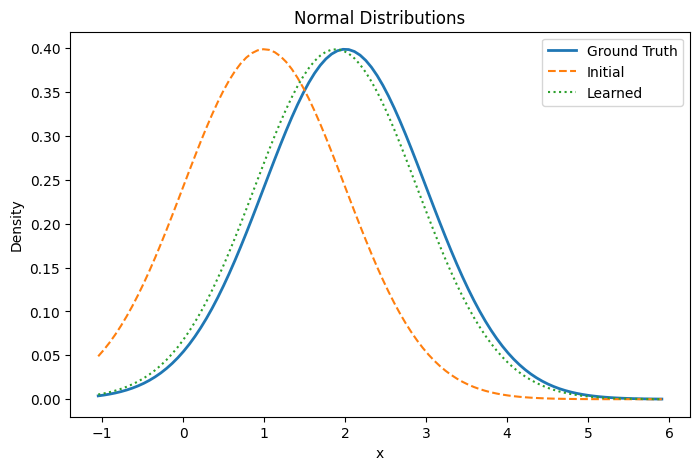

In [37]:
plt.figure(figsize=(8,5))

plt.plot(x, ground_truth_dist.pdf(x), label="Ground Truth", linewidth=2)
plt.plot(x, initial_dist.pdf(x), label="Initial", linestyle="--")
plt.plot(x, estimated_dist.pdf(x), label="Learned", linestyle=":")

plt.title("Normal Distributions")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()

plt.show()

In [8]:
import numpy as np
from sympy import symbols, exp, sqrt, pi, log, lambdify
from partialDerivator import cost_function, gradient_descent, compute_loglikelihood, get_normal_density_value

x, mu, sigma = symbols('x mu sigma', real=True)
def normal_density(x, mu, sigma):
    coeff = 1 / (sqrt(2 * pi) * sigma)
    exponent = exp(-(x - mu)**2 / (2 * sigma**2))
    return coeff * exponent
normal_dist = (1 / (sqrt(2*pi)*sigma)) * exp(-(x - mu)**2 / (2*sigma**2))

logpdf = log(normal_dist)

logpdf_func = lambdify(
    (x, mu, sigma),
    logpdf,
    'numpy'
)

mu_true = 2
sigma = 1
n = 500

x_samples = np.random.normal(mu_true, sigma, n)
x_samples = samples_list

mu_1 = 2
mu_2 = 7

logL_mu2 = np.sum(logpdf_func(x_samples, mu_1, sigma))
logL_mu7 = np.sum(logpdf_func(x_samples, mu_2, sigma))

normal_dist1 = normal_dist.subs({sigma:1, mu:mu_1})
normal_dist2 = normal_dist.subs({sigma:1, mu:mu_2})

print( compute_loglikelihood(x_samples, normal_density(x_samples,mu,sigma), ({'mu':mu_1, 'sigma':1})))
print( compute_loglikelihood(x_samples, normal_density(x_samples,mu,sigma), ({'mu':mu_2, 'sigma':1})))

print("log L(mu=2):", logL_mu2)
print("log L(mu=7):", logL_mu7)
print("Diferença:", logL_mu2 - logL_mu7)

print(get_normal_density_value(x_samples[1], sigma, mu_1))
print(get_normal_density_value(x_samples[1], sigma, mu_2))

-204.61031436013516
-1460.762126974557
log L(mu=2): -204.6103143601351
log L(mu=7): -1460.762126974557
Diferença: 1256.151812614422
0.09318690365613927
6.877423148008607e-11


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sympy/functions/elementary/exponential.py:87: SymPyDeprecationWarning: 

Using non-Expr arguments in Mul is deprecated (in this case, one of
the arguments has type 'ImmutableDenseNDimArray').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#non-expr-args-deprecated
for details.

This has been deprecated since SymPy version 1.7. It
will be removed in a future version of SymPy.

  return self.func(1), Mul(*self.args)


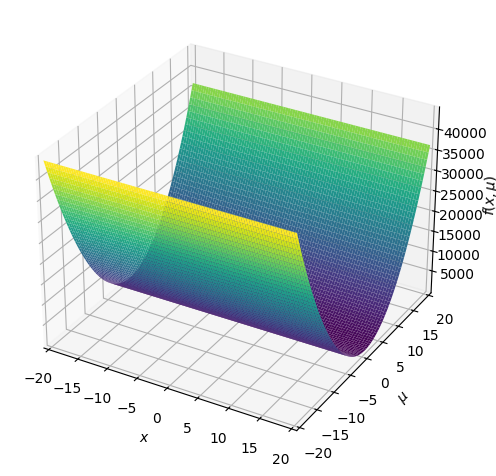

Best mu: 0
Initial loss: 402.1495893143662, Final loss: 402.1495893143662


In [10]:
import sympy as sp
from sympy import Array
from sympy.plotting import plot3d,  plot
from partialDerivator import cost_function, gradient_descent, cost_function

x, sigma, mu = sp.symbols('x sigma mu')
f = cost_function(x_bold=samples_list, mu=mu, sigma=1)
plot3d(f, (x, -20, 20), (mu, -20, 20))
x_bold = samples_list
best_mu = gradient_descent(func=f, var=mu, datapoints=x_bold, learning_rate=0.01, iterations=100)

print(f"Best mu: {best_mu}")
initial_loss = cost_function(x_bold=samples_list, mu=0, sigma=1)
final_loss = cost_function(x_bold=samples_list, mu=best_mu, sigma=1)
print(f"Initial loss: {float(initial_loss)}, Final loss: {float(final_loss)}")







Best mu: 0.904610278102844
Initial loss: 89.28870502863468, Final loss: 64.73911237115551